# BO smoke test — replay & inspect on saved data (no microscope)

**What this is.** A quick sanity check you run **before** committing to a real 7-hour BO experiment. It loads a previous run's saved measurements and replays the new acquisition pipeline on top of them, simulating a few BO phases with synthetic measurements. Each cell prints or plots one piece of state so you can read the algorithm's behaviour like a story.

**What it catches** (this batch caught all of these):
- the `gpax.predict_in_batches` NaN-batch bug (manifests as picks pinned to one extreme)
- broken acquisition (`min == max`, all NaN, all 0)
- model-selection state corruption (no candidate ever wins)
- missing `__init__` arguments after a refactor
- AUC-vs-frac task imbalance

**What it doesn't replace.** Real microscope behaviour, real cell variability, FOV-finder logic, image processing, MCMC convergence at production budgets. So *don't* skip the dry-run on a real plate before a multi-hour experiment — but if this notebook fails, *definitely don't* dry-run a plate.

**How to read it.** Every code cell prints or plots something interpretable. If a cell prints `OK` or shows a sensible-looking figure, that piece works. If it says `WARN` or a figure is all-zero, something is off and the next-cell text explains what to look at.

Configuration: `DATA_PATH` below points to your saved checkpoint parquet. Update it if you want to test against a different prior run.

In [1]:
# --- gpax/numpyro shim (same as v1) -----------------------------------------
import os, logging

os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*a, **k):
    raise NotImplementedError("viDKL not available")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

# Enable float64 BEFORE any gpax operations -- gpax 0.1.9 has a Cholesky-
# instability bug in float32 that produces ~99% NaN in predict() outputs.
import gpax.utils as _gpax_utils

_gpax_utils.enable_x64()

from faro.agents.bo_optimization import BO_Parameter, BO_Objective, BO_Covariate
from faro.core.data_structures import PowerChannel
from faro.agents.two_task_dose_response import (
    TwoTaskDoseResponseBO,
    DEFAULT_CANDIDATE_HYPOTHESES,
    _logit,
    _inv_logit,
)

# --- Where to load saved data from ------------------------------------------
DATA_PATH = r"E:/Alex/2026-05-04_bo_erk_dose_response_v1/bo_results_checkpoint.parquet"

# Reduced MCMC budget so each simulated phase takes ~30-60 s instead of
# the production 5+ min. Bumped up if you see noisy posteriors.
MCMC_WARMUP = 200
MCMC_SAMPLES = 400

# How many BO phases to simulate. With n_warmup_phases=3 below, the first 3 are
# warmup (fit-all-candidates) and the remaining 2 are eps-greedy demonstrations.
N_SIM_PHASES = 5

print(f"DATA_PATH = {DATA_PATH}")
print(
    f"MCMC_WARMUP={MCMC_WARMUP}, MCMC_SAMPLES={MCMC_SAMPLES}, N_SIM_PHASES={N_SIM_PHASES}"
)

DATA_PATH = E:/Alex/2026-05-04_bo_erk_dose_response_v1/bo_results_checkpoint.parquet
MCMC_WARMUP=200, MCMC_SAMPLES=400, N_SIM_PHASES=5


## 1. Load the saved measurements

Should print 162 rows and a list of pulse durations spanning ~20-5000 ms. If you see fewer rows or a missing column, the saved parquet was generated by a different version of the agent — pick a more recent checkpoint.

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df)} rows. Columns: {list(df.columns)}")
expected = {
    "pulse_duration",
    "n_cells",
    "baseline_cnr",
    "optortk_expression",
    "mean_delta_auc",
    "frac_peak_responders",
}
missing = expected - set(df.columns)
if missing:
    print(f"WARN: missing expected columns: {missing}")
else:
    print("OK: all expected columns present")

print(f"\nPer-pulse_duration sample counts:")
print(df.groupby("pulse_duration").size().sort_index())
print(f"\nObjective summaries:")
print(df[["mean_delta_auc", "frac_peak_responders"]].describe().round(3))

Loaded 162 rows. Columns: ['pulse_duration', 'n_cells', 'baseline_cnr', 'optortk_expression', 'mean_delta_auc', 'frac_peak_responders']
OK: all expected columns present

Per-pulse_duration sample counts:
pulse_duration
20.0      6
110.0     6
200.0     6
320.0     6
440.0     6
770.0     6
1000.0    6
1580.0    6
2300.0    6
2720.0    6
3290.0    6
3860.0    6
4230.0    6
4490.0    6
4880.0    6
4890.0    6
4900.0    6
4910.0    6
4920.0    6
4930.0    6
4940.0    6
4950.0    6
4960.0    6
4970.0    6
4980.0    6
4990.0    6
5000.0    6
dtype: int64

Objective summaries:
       mean_delta_auc  frac_peak_responders
count         162.000               162.000
mean            4.239                 0.030
std             2.413                 0.034
min            -0.666                 0.000
25%             1.916                 0.000
50%             5.100                 0.019
75%             6.069                 0.047
max             8.905                 0.126


## 2. Quick visual: dose-response from raw data

Before fitting any GP, just look at the raw measurements. A clean dose-response should show AUC rising with dose. If the data looks flat/noisy here, no model is going to recover a meaningful curve.

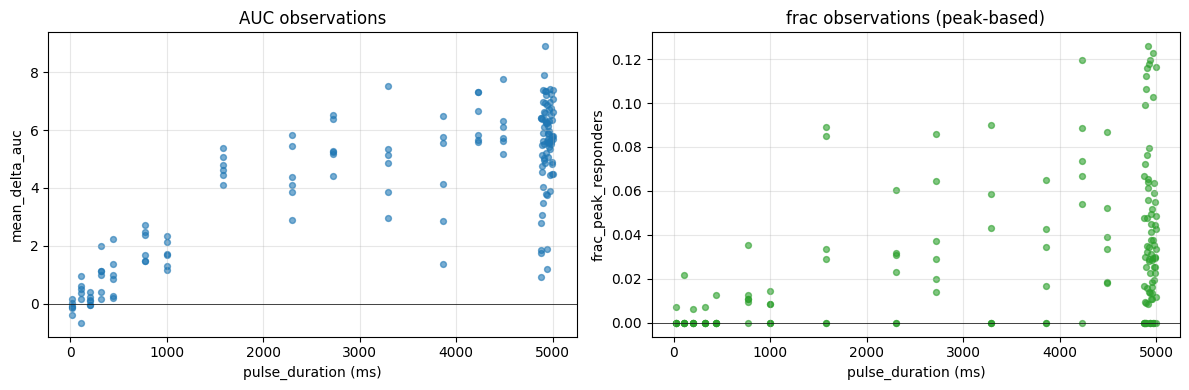

frac_peak_responders is exactly 0 in 53/162 FOVs (33%)


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(df["pulse_duration"], df["mean_delta_auc"], alpha=0.6, s=18)
ax1.set_xlabel("pulse_duration (ms)")
ax1.set_ylabel("mean_delta_auc")
ax1.set_title("AUC observations")
ax2.scatter(
    df["pulse_duration"], df["frac_peak_responders"], alpha=0.6, s=18, color="C2"
)
ax2.set_xlabel("pulse_duration (ms)")
ax2.set_ylabel("frac_peak_responders")
ax2.set_title("frac observations (peak-based)")
for ax in (ax1, ax2):
    ax.axhline(0, color="k", lw=0.5)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_zero_frac = (df["frac_peak_responders"] == 0).sum()
print(
    f"frac_peak_responders is exactly 0 in {n_zero_frac}/{len(df)} FOVs ({100*n_zero_frac/len(df):.0f}%)"
)
if n_zero_frac > 0.5 * len(df):
    print(
        "  -> >=50% zeros: frac task signal is sparse; AUC-primary acquisition is appropriate."
    )

## 3. Build the agent (no microscope)

Same constructor args as the v1 production notebook, except we pass dummy `imaging_channels` / `stim_channel` (we never call the microscope) and reduce the MCMC budget for speed.

If this cell fails, the agent's `__init__` signature has drifted from v1's call site.

In [4]:
imaging_channels = (PowerChannel(config="x", exposure=100, group="g", power=10),)
stim_channel = PowerChannel(config="x", exposure=100, group="g", power=10)

agent = TwoTaskDoseResponseBO(
    storage_path="C:/tmp/bo_smoke_test",
    n_frames_baseline=10,
    n_frames_observation=20,
    time_between_timesteps=60,
    imaging_channels=imaging_channels,
    stim_channel=stim_channel,
    optocheck_channel=None,
    min_track_fraction=0.8,
    max_baseline_cnr=1.0,
    save_checkpoints=False,
    plot_live=False,
    parameters_to_optimize=[
        BO_Parameter(name="pulse_duration", bounds=(0.0, 5000.0), spacing=10.0)
    ],
    objective_metric=BO_Objective(name="mean_delta_auc", goal="maximize"),
    bo_covariates=[
        BO_Covariate(name="n_cells"),
        BO_Covariate(name="optortk_expression", log_scale=True),
        BO_Covariate(name="baseline_cnr"),
    ],
    n_iterations=13,
    n_conditions_per_iter=3,
    n_initial_phases=2,
    n_cov_samples=20,
    ei_num_samples=4,
    ei_noiseless=True,
    verbose=True,
    penalty="inverse_distance",
    penalty_factor=2.0,
    batch_penalty_factor=10,
    candidate_hypotheses_auc=dict(DEFAULT_CANDIDATE_HYPOTHESES),
    candidate_hypotheses_frac=dict(DEFAULT_CANDIDATE_HYPOTHESES),
    eps_greedy_eps=0.3,
    n_warmup_phases=3,
    frac_acq_weight=0.3,
    lengthscale_prior_dist=dist.Uniform(0.1, 1.0),
    peak_ratio=1.5,
    peak_min_consecutive_frames=2,
    gp_kernel="Matern",
    gp_num_warmup=MCMC_WARMUP,
    gp_num_samples=MCMC_SAMPLES,
    rng_seed=42,
)

print("Agent built OK")
print(f"  n_warmup_phases  = {agent.n_warmup_phases}")
print(f"  eps_greedy_eps   = {agent.eps_greedy_eps}")
print(f"  frac_acq_weight  = {agent.frac_acq_weight}")
print(f"  peak_ratio       = {agent.peak_ratio}")
print(f"  candidates       = {list(agent.candidate_hypotheses_by_task['auc'])}")

Agent built OK
  n_warmup_phases  = 3
  eps_greedy_eps   = 0.3
  frac_acq_weight  = 0.3
  peak_ratio       = 1.5
  candidates       = ['hill', 'linear', 'exponential']


## 4. Prime the agent with the saved data

Normally the framework populates `df_results`, `x_unmeasured`, and `x_performed_experiments` over the course of the run. Here we hand-feed them with the saved checkpoint as if those phases had just completed.

In [5]:
# Full grid the agent treats as the search space.
full_grid = np.arange(0.0, 5000.0 + 0.5 * 10.0, 10.0).reshape(-1, 1)
agent.x_total_linespace = np.column_stack(
    [
        full_grid.flatten(),
        np.zeros(len(full_grid)),
        np.ones(len(full_grid)),
        np.ones(len(full_grid)),
    ]
)  # placeholder covariate cols; only the dose col is used by the BO

# x_unmeasured = full grid minus already-measured doses
measured = np.unique(df["pulse_duration"].values)
mask = ~np.isin(full_grid[:, 0], measured)
agent.x_unmeasured = full_grid[mask].copy()
agent.x_performed_experiments = df["pulse_duration"].values.reshape(-1, 1)
agent.df_results = df.copy()

print(f"x_unmeasured: {agent.x_unmeasured.shape[0]} grid points")
print(
    f"x_performed_experiments: {agent.x_performed_experiments.shape[0]} prior measurements"
)
print(
    f"unique doses already measured: {len(measured)} ({measured.min():.0f} - {measured.max():.0f} ms)"
)

x_unmeasured: 474 grid points
x_performed_experiments: 162 prior measurements
unique doses already measured: 27 (20 - 5000 ms)


## 5. Simulate `N_SIM_PHASES` BO phases (each picks `n_conditions_per_iter` doses)

Each phase mimics the real microscope cycle: refit the two-task GPs, then sequentially pick `n_conditions_per_iter` doses (3 by default) using the framework's batch-greedy logic.

* **Pick 1**: full GP fit on the data so far. Cross-phase `inverse_distance` penalty applies (against all prior measurements).
* **Picks 2, 3**: GP fit cached from pick 1 (no refit, much faster). Within-batch `inverse_distance` penalty with `batch_penalty_factor=10` pushes them away from pick 1 (and from each other).

After the batch is complete, we append `n_conditions_per_iter` synthetic measurements (one per pick, using the median observed AUC / frac as a stand-in for the real biology) so the next phase sees +3 datapoints.

**What you should see** for a healthy run:
* The first `n_warmup_phases=3` phases run `warmup phase i/3 -- fitting all 3 candidates` for each task before printing the 3 condition lines.
* Pick 1 takes the bulk of each phase (full MCMC fit, ~2-3 min). Picks 2 and 3 are 2-5x faster because the GP fit is cached.
* The 3 picks within each phase land at distinct doses (within-batch penalty working).
* Acquisition spread is non-trivial (>0.01).
* Picks land in 1000-3500 ms most of the time (transition zone), not pinned to 4900 ms.

**Red flags**:
* All 3 picks of a phase are identical → within-batch penalty broken.
* Pick 2 takes as long as pick 1 → cache not reused.
* `acq stats min == max` → acquisition degenerate.
* Picks pinned to one extreme → cross-phase penalty being overwhelmed.


In [6]:
np.random.seed(0)  # reproducible eps-greedy

df_cur = df.copy()
synthetic_y_auc = float(df["mean_delta_auc"].median())
synthetic_y_frac = float(df["frac_peak_responders"].median())

phase_records = []  # one row per phase: {phase, picks: [(dose, elapsed), ...]}
n_conditions = agent.n_conditions_per_iter  # 3 by default

for phase_i in range(N_SIM_PHASES):
    print(
        f"\n========== Simulated BO phase {phase_i + 1}/{N_SIM_PHASES}  "
        f"(picking {n_conditions} doses) =========="
    )
    agent._current_phase_id = 9 + phase_i

    # Mimic the framework's _select_batch_parameters: keep the GP fit cached
    # for picks 2..n_conditions and apply the within-batch penalty.
    agent._cached_gp_fit = None
    agent._batch_fit_reuse = True
    orig_penalty = agent.penalty
    orig_penalty_factor = agent.penalty_factor

    batch_picks = []
    try:
        for cond_i in range(n_conditions):
            if cond_i > 0:
                agent.penalty = "inverse_distance"
                agent.penalty_factor = agent.batch_penalty_factor
            t0 = time.time()
            pick = agent._determine_next_parameters(df_cur, verbose=False)
            elapsed = time.time() - t0
            pulse = pick["pulse_duration"]
            batch_picks.append((pulse, elapsed))
            print(
                f"  -> condition {cond_i + 1}/{n_conditions}: "
                f"pulse_duration = {pulse:.0f} ms  [{elapsed:.1f}s]"
            )
    finally:
        agent.penalty = orig_penalty
        agent.penalty_factor = orig_penalty_factor
        agent._batch_fit_reuse = False
        agent._cached_gp_fit = None

    phase_records.append({"phase": phase_i, "picks": batch_picks})

    # One synthetic measurement per pick so the next phase sees +n_conditions points.
    new_rows = [
        {
            "pulse_duration": pulse,
            "n_cells": 100.0,
            "optortk_expression": 1300.0,
            "baseline_cnr": 0.6,
            "mean_delta_auc": synthetic_y_auc,
            "frac_peak_responders": synthetic_y_frac,
        }
        for pulse, _ in batch_picks
    ]
    df_cur = pd.concat([df_cur, pd.DataFrame(new_rows)], ignore_index=True)
    agent.x_performed_experiments = df_cur["pulse_duration"].values.reshape(-1, 1)

print("\n========== summary ==========")
header = "phase " + "  ".join([f"  pick{i+1} (s)" for i in range(n_conditions)])
print(header)
print("-" * len(header))
for rec in phase_records:
    row = f"{rec['phase']:5d} "
    for pulse, t in rec["picks"]:
        row += f"  {pulse:>5.0f} ({t:>4.1f})"
    print(row)


========== Simulated BO phase 1/5  (picking 3 doses) ==========
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: warmup phase 1/3 -- fitting all 3 candidates]
      hill: obj=0.0325, log_evidence=-8.268
      linear: obj=0.0314, log_evidence=-4.283
      exponential: obj=0.0322, log_evidence=-7.855
    [auc: warmup winner='linear', obj=0.0314]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: warmup phase 1/3 -- fitting all 3 candidates]
      hill: obj=0.1368, log_evidence=-92.710
      linear: obj=0.1294, log_evidence=-101.719
      exponential: obj=0.1366, log_evidence=-98.132
    [frac: warmup winner='linear', obj=0.1294]
  AUC-primary acq stats (frac_w=0.3): min=-0.1175, max=0.0609
  -> condition 1/3: pulse_duration = 1940 ms  [201.5s]
  [reusing cached two-task GP fits from earlier in this batch]
  AUC-primary acq stats (frac_w=0.3): min=-0.0220, max=0.0105
  -> condition 2/3: pulse_duration = 2510 ms  [127.5s]
  [reusing c

## 6. Inspect the LAST phase's acquisition landscape

What did the agent *see* on the final phase? The plot below shows:
- top: AUC posterior mean ± std overlaid with the actual measurements (black scatter)
- middle: frac posterior mean (in logit space, since that's what the GP fits)
- bottom: the joint acquisition `z(var_auc) + frac_acq_weight * z(var_frac)` after cross-phase penalty, with a red dashed line at the picked dose

**What to look for:**
- AUC mean curve resembles a saturating dose-response, not a flat line and not wild oscillations.
- Acquisition is NOT all zero, NOT all NaN, and the picked dose corresponds to a clear peak.
- The picked dose is NOT one we already measured (red dashed line should be on a tick that has no black dot).

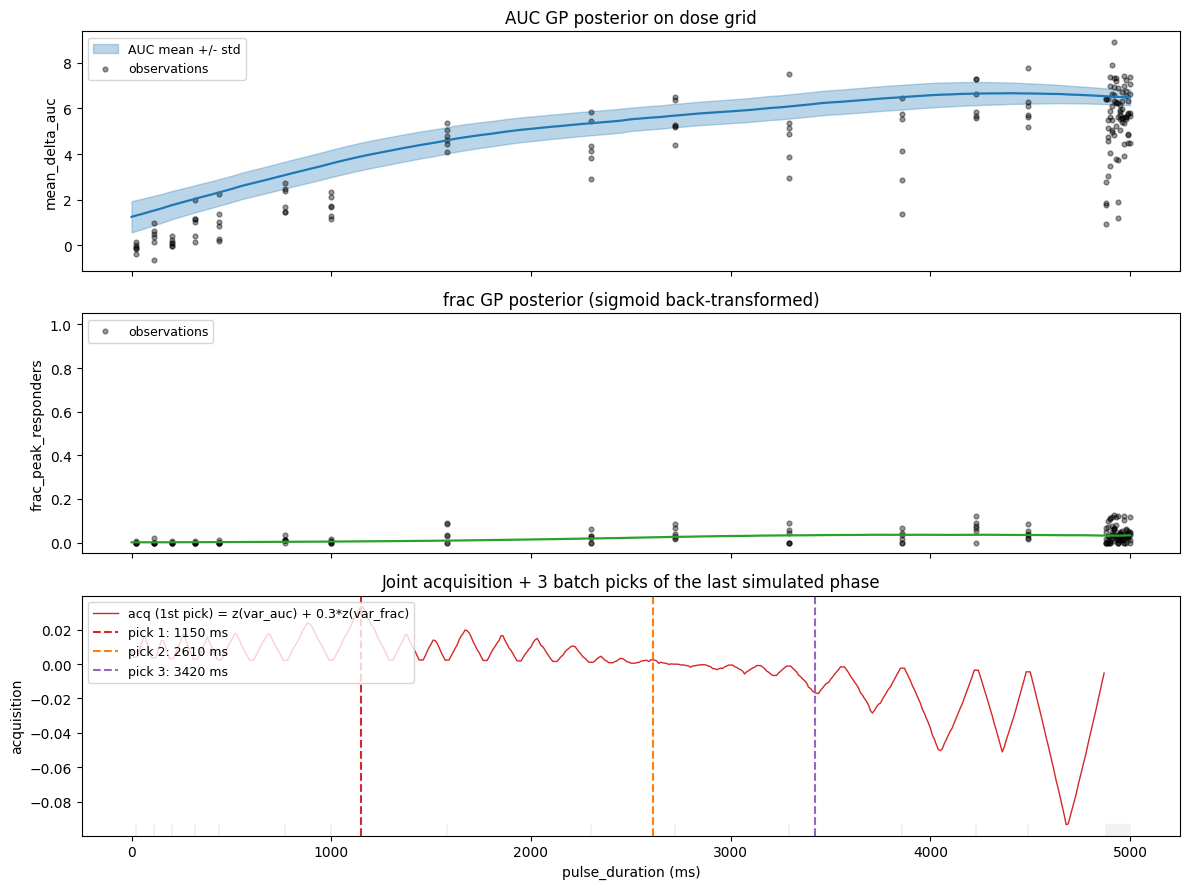


acq stats (last phase, 1st pick): min=-0.0934, max=0.0335, std=0.0215
  -> spread is OK (>0.01)


In [7]:
ctx = agent._last_plot_context
x_un = ctx["x_unmeasured_at_computation"][:, 0]
acq = ctx["acq_values_total"]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# AUC posterior mean+std and observations
x_scaler = ctx["x_scaler"]
y_scaler_auc = ctx["y_scalers_by_task"]["auc"]
rng_pred = ctx["rng_key_predict"]
gp_auc = ctx["gp_models_by_task"]["auc"]

vis_doses = np.arange(0.0, 5001.0, 50.0)
cov_med = np.median(
    df[["n_cells", "optortk_expression", "baseline_cnr"]].values, axis=0
)
X_vis_raw = np.column_stack([vis_doses, np.tile(cov_med, (len(vis_doses), 1))])
X_vis_scaled = x_scaler.transform(X_vis_raw)
_, samples_auc = gp_auc.predict_in_batches(
    rng_pred, X_vis_scaled, batch_size=50, n=4, noiseless=True
)
samples_auc = np.asarray(samples_auc).reshape(-1, len(vis_doses))
mean_auc_z = np.nanmedian(samples_auc, 0)
std_auc_z = np.nanstd(samples_auc, 0)
mean_auc = y_scaler_auc.inverse_transform(mean_auc_z.reshape(-1, 1)).flatten()
std_auc = std_auc_z * float(y_scaler_auc.std_[0])

ax = axes[0]
ax.fill_between(
    vis_doses,
    mean_auc - std_auc,
    mean_auc + std_auc,
    alpha=0.3,
    color="C0",
    label="AUC mean +/- std",
)
ax.plot(vis_doses, mean_auc, color="C0", lw=1.6)
ax.scatter(
    df["pulse_duration"],
    df["mean_delta_auc"],
    s=12,
    c="k",
    alpha=0.4,
    label="observations",
)
ax.set_ylabel("mean_delta_auc")
ax.set_title("AUC GP posterior on dose grid")
ax.legend(loc="upper left", fontsize=9)

# frac posterior
y_scaler_frac = ctx["y_scalers_by_task"]["frac"]
gp_frac = ctx["gp_models_by_task"]["frac"]
_, samples_frac = gp_frac.predict_in_batches(
    rng_pred, X_vis_scaled, batch_size=50, n=4, noiseless=True
)
samples_frac = np.asarray(samples_frac).reshape(-1, len(vis_doses))
mean_frac_z = np.nanmedian(samples_frac, 0)
mean_frac_logit = y_scaler_frac.inverse_transform(mean_frac_z.reshape(-1, 1)).flatten()
mean_frac_prob = _inv_logit(mean_frac_logit)
ax = axes[1]
ax.plot(vis_doses, mean_frac_prob, color="C2", lw=1.6)
ax.scatter(
    df["pulse_duration"],
    df["frac_peak_responders"],
    s=12,
    c="k",
    alpha=0.4,
    label="observations",
)
ax.set_ylabel("frac_peak_responders")
ax.set_title("frac GP posterior (sigmoid back-transformed)")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper left", fontsize=9)

# Joint acquisition (1st pick) + ALL n_conditions picks of the last phase
ax = axes[2]
ax.plot(
    x_un,
    acq,
    color="C3",
    lw=1.0,
    label=f"acq (1st pick) = z(var_auc) + {agent.frac_acq_weight}*z(var_frac)",
)
last_batch = phase_records[-1]["picks"]
colors_picks = ["C3", "C1", "C4", "C5"]
for i, (pulse, _) in enumerate(last_batch):
    ax.axvline(
        pulse,
        ls="--",
        color=colors_picks[i % len(colors_picks)],
        lw=1.5,
        label=f"pick {i+1}: {pulse:.0f} ms",
    )
for d in measured:
    ax.axvline(d, color="k", lw=0.3, alpha=0.25, ymax=0.05)
ax.set_xlabel("pulse_duration (ms)")
ax.set_ylabel("acquisition")
ax.set_title(
    f"Joint acquisition + {len(last_batch)} batch picks of the last simulated phase"
)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

print(
    f"\nacq stats (last phase, 1st pick): "
    f"min={np.nanmin(acq):.4f}, max={np.nanmax(acq):.4f}, std={np.nanstd(acq):.4f}"
)
spread = float(np.nanmax(acq) - np.nanmin(acq))
print(f"  -> spread is {'OK (>0.01)' if spread > 0.01 else 'TOO TIGHT'}")

## 7. Inspect the hypothesis-learning state

After warmup (2 phases of fit-all-candidates), each task should have:
- `record[:, 0] == [n_warmup_phases, n_warmup_phases, n_warmup_phases]` — every candidate visited each warmup phase
- `record[:, 1]` summing to ~1.0 across the 3 candidates — i.e., proper win-frequency normalisation

After warmup, `record[:, 0]` increments only for whichever model eps-greedy picks; `record[:, 1]` is now the running mean reward and can drift away from the warmup frequencies.

If the AUC table looks reasonable (one model with mean reward > 0, others < 0) by the last phase, eps-greedy is doing its job.

In [8]:
for task in agent.TASKS:
    state = agent._task_state[task]
    candidates = list(agent.candidate_hypotheses_by_task[task])
    record = state["record"]
    print(f"=== task {task!r} ===")
    print(
        f"  warmup phases done: {state['n_warmup_phases_done']}/{agent.n_warmup_phases}"
    )
    print(
        f"  current favourite (argmax of mean reward): {state['selected_hypothesis']!r}"
    )
    print(f"  reward record:")
    print(f"    {'candidate':<12s}  {'visit_count':>11s}  {'mean_reward':>11s}")
    for i, name in enumerate(candidates):
        print(f"    {name:<12s}  {int(record[i, 0]):>11d}  {record[i, 1]:>+11.3f}")
    print(f"  obj_history (median predictive variance per phase):")
    print(
        f"    {[f'{v:.4f}' if np.isfinite(v) else 'nan' for v in state['obj_history']]}"
    )
    print()

=== task 'auc' ===
  warmup phases done: 3/3
  current favourite (argmax of mean reward): 'linear'
  reward record:
    candidate     visit_count  mean_reward
    hill                    3       +0.000
    linear                  5       +0.600
    exponential             3       +0.000
  obj_history (median predictive variance per phase):
    ['0.0314', '0.0336', '0.0330', '0.0327', '0.0333']

=== task 'frac' ===
  warmup phases done: 3/3
  current favourite (argmax of mean reward): 'linear'
  reward record:
    candidate     visit_count  mean_reward
    hill                    3       +0.000
    linear                  5       +0.600
    exponential             3       +0.000
  obj_history (median predictive variance per phase):
    ['0.1294', '0.1295', '0.1308', '0.1304', '0.1338']



## 8. Pass / fail checklist

Cell below tabulates everything and prints `PASS` or `FAIL` for each check. If all green, the agent's algorithmic pipeline is in good shape and you can run on the real microscope.

In [9]:
checks = []

# C1: data loaded
c1 = expected.issubset(df.columns) and len(df) > 50
checks.append(("data_loaded_with_required_columns", c1, f"{len(df)} rows"))

# C2: agent built with new params
c2 = all(
    hasattr(agent, k)
    for k in [
        "eps_greedy_eps",
        "n_warmup_phases",
        "frac_acq_weight",
        "peak_ratio",
        "rng_seed",
    ]
)
checks.append(
    (
        "agent_has_new_params",
        c2,
        "all expected attrs present" if c2 else "missing attrs",
    )
)

# C3: every phase yielded n_conditions distinct picks (within-batch penalty works)
all_distinct_per_phase = all(
    len(set(p[0] for p in rec["picks"])) == agent.n_conditions_per_iter
    for rec in phase_records
)
all_picks = [p[0] for rec in phase_records for p in rec["picks"]]
all_extreme = all(p <= 50 or p >= 4950 for p in all_picks)
c3 = all_distinct_per_phase and (not all_extreme)
checks.append(
    (
        "each_phase_picks_n_distinct_doses_not_all_extreme",
        c3,
        f"distinct/phase = {[len(set(p[0] for p in rec['picks'])) for rec in phase_records]}; "
        f"all_extreme={all_extreme}",
    )
)

# C4: cache reuse -- picks 2+ are faster than pick 1
cache_speedup_ok = all(
    rec["picks"][i][1] < 0.6 * rec["picks"][0][1]
    for rec in phase_records
    for i in range(1, len(rec["picks"]))
)
ratios = [
    [
        round(rec["picks"][i][1] / rec["picks"][0][1], 2)
        for i in range(len(rec["picks"]))
    ]
    for rec in phase_records
]
checks.append(
    ("cache_reuse_makes_subsequent_picks_faster", cache_speedup_ok, f"ratios={ratios}")
)

# C5: acquisition has non-trivial spread on the LAST phase
acq_spread = float(np.nanmax(acq) - np.nanmin(acq))
c5 = np.isfinite(acq_spread) and acq_spread > 0.01
checks.append(
    ("acquisition_has_meaningful_spread", c5, f"acq spread = {acq_spread:.4f}")
)

# C6: warmup completed
c6 = all(
    agent._task_state[t]["n_warmup_phases_done"]
    >= min(N_SIM_PHASES, agent.n_warmup_phases)
    for t in agent.TASKS
)
checks.append(
    (
        "warmup_progressed_correctly",
        c6,
        f"warmup done per task: {[agent._task_state[t]['n_warmup_phases_done'] for t in agent.TASKS]}",
    )
)

# C7: reward signal is finite for at least one task
any_finite = any(
    np.isfinite(v) for t in agent.TASKS for v in agent._task_state[t]["obj_history"]
)
checks.append(
    ("reward_signal_finite", any_finite, "some obj_history entries are finite")
)

print(f"{'check':<55s}  {'result':>6s}  {'detail':<60s}")
print("-" * 130)
for name, ok, detail in checks:
    print(f"{name:<55s}  {'PASS' if ok else 'FAIL':>6s}  {detail:<60s}")
n_pass = sum(ok for _, ok, _ in checks)
print("-" * 130)
print(
    f"\n{'ALL PASS' if n_pass == len(checks) else f'{n_pass}/{len(checks)} PASS -- review failures'}"
)

check                                                    result  detail                                                      
----------------------------------------------------------------------------------------------------------------------------------
data_loaded_with_required_columns                          PASS  162 rows                                                    
agent_has_new_params                                       PASS  all expected attrs present                                  
each_phase_picks_n_distinct_doses_not_all_extreme          PASS  distinct/phase = [3, 3, 3, 3, 3]; all_extreme=False         
cache_reuse_makes_subsequent_picks_faster                  FAIL  ratios=[[1.0, 0.63, 0.65], [1.0, 0.54, 0.51], [1.0, 0.55, 0.58], [1.0, 0.8, 0.74], [1.0, 0.8, 0.76]]
acquisition_has_meaningful_spread                          PASS  acq spread = 0.1269                                         
warmup_progressed_correctly                                PASS  warmup d